<h1 style="text-align: center; font-family: 'menlo'; color: #FFF243; font-size:50px;">
  <span style="background-color: #FA9500; padding: 5px 10px; border-radius: 5px; display: inline-block;">
         Combine bias images to make master
  </span>
</h1>

The final step is to combine the individual calibrated bias images into a <u>single combined image.</u> That combined image will have less noise than the individual images, minimizing the noise added to the remaining images when the bias is subtracted.

Regardless of which path you took through the calibration of the biases (with overscan or without), there should be a folder named <span style="color: #d62495">reduced</span> that contains the calibrated bias images. If there is not, please run the previous notebook before continuing with this one.

In [1]:
from pathlib import Path
from astropy.nddata import CCDData
from astropy.stats import mad_std

import ccdproc as ccdp
import matplotlib.pyplot as plt
import numpy as np

from convenience_functions import show_image
plt.style.use('guide.mplstyle')

# Recommended settings for image combination

As discussed in the [notebook about combining images](https://www.astropy.org/ccd-reduction-and-photometry-guide/v/dev/notebooks/01-06-Image-combination.html), the recommendation is that you combine by averaging the individual images but sigma clip to remove extreme values.

[ccdproc](https://ccdproc.readthedocs.org/) provides two ways to combine: 

- An object-oriented interface built around the <span style="color: #d62495">Combiner</span> object, described in the [ccdproc documentation on image combination](https://ccdproc.readthedocs.io/en/latest/image_combination.html).

- A function called [combine](https://ccdproc.readthedocs.io/en/latest/api/ccdproc.combine.html#ccdproc.combine), which we will use here because the function allows you to specify the maximum amount of memory that should be used during combination. This feature can be essential depending on how many images you need to combine, how big they are, and how much memory your computer has.

**NOTE: If using a version of ccdproc lower than 2.0, set the memory limit a factor of 2-3 lower than you want the maximum memory consumption to be.**

# Example 1: Cryogenically-cooled camera

The remainder of this section assumes the calibrated bias images are in the folder <span style="color: #d62495">example1-reduced</span> which is created in the previous notebook.

In [2]:
calibrated_path = Path('example1-reduced')
reduced_images = ccdp.ImageFileCollection(calibrated_path)

The code below:

- selects the calibrated bias images,

- combines them using the <span style="color: #d62495">combine</span> function,

- adds the keyword <span style="color: #d62495">COMBINED</span> to the header so that later calibration steps can easily identify which bias to use, and

- writes the file.

In [3]:
calibrated_biases = reduced_images.files_filtered(imagetyp='bias', include_path=True)

combined_bias = ccdp.combine(calibrated_biases,
                            method='average',
                            sigma_clip=True, sigma_clip_low_thresh=5, sigma_clip_high_thresh=5,
                            sigma_clip_func=np.ma.median, sigma_clip_dev_func=mad_std,
                            mem_limit=350e6)
    # sigma_clip=True -> remove pixels outliers
    # sigma_clip_low_thresh=5 -> remove pixels abaixo de 5 desvios padrão da mediana
    # sigma_clip_high_thresh=5 -> remove pixels acima de 5 desvios padrão da mediana
    # sigma_clip_func=np.ma.median -> usa a mediana como referência para o corte
    # sigma_clip_dev_func=mad_std -> usa MAD para estimar o desvio padrão
    # mem_limit=350e6 -> limite de memória de 350 milhões de bytes (~350 MB) para o processamento

combined_bias.meta['combined']=True
    # combined_bias.meta -> acessa o dicionário de metadados da imagem (cabeçalho)
    # ['combined']=True -> Adiciona uma nova palavra-chave no cabeçalho chamada COMBINED com valor True
    #  serve para lembrar mais tarde que esta imagem não é uma imagem crua, mas sim uma imagem combinada. 
        # útil para rastrear o que você já processou.
combined_bias.write(calibrated_path / 'combined_bias.fit') #save

INFO:astropy:splitting each image into 7 chunks to limit memory usage to 350000000.0 bytes.


INFO: splitting each image into 7 chunks to limit memory usage to 350000000.0 bytes. [ccdproc.combiner]


## Result for Example 1

A single calibrated image and the combined image are shown below. There is significant two-dimensional structure in the bias that cannot easily be removed by subtracting only the overscan in the next image reduction steps. It takes little time to acquire bias images and doing so <u>will result in higher quality science images.</u>

Text(0.5, 1.0, '6 bias images combined')

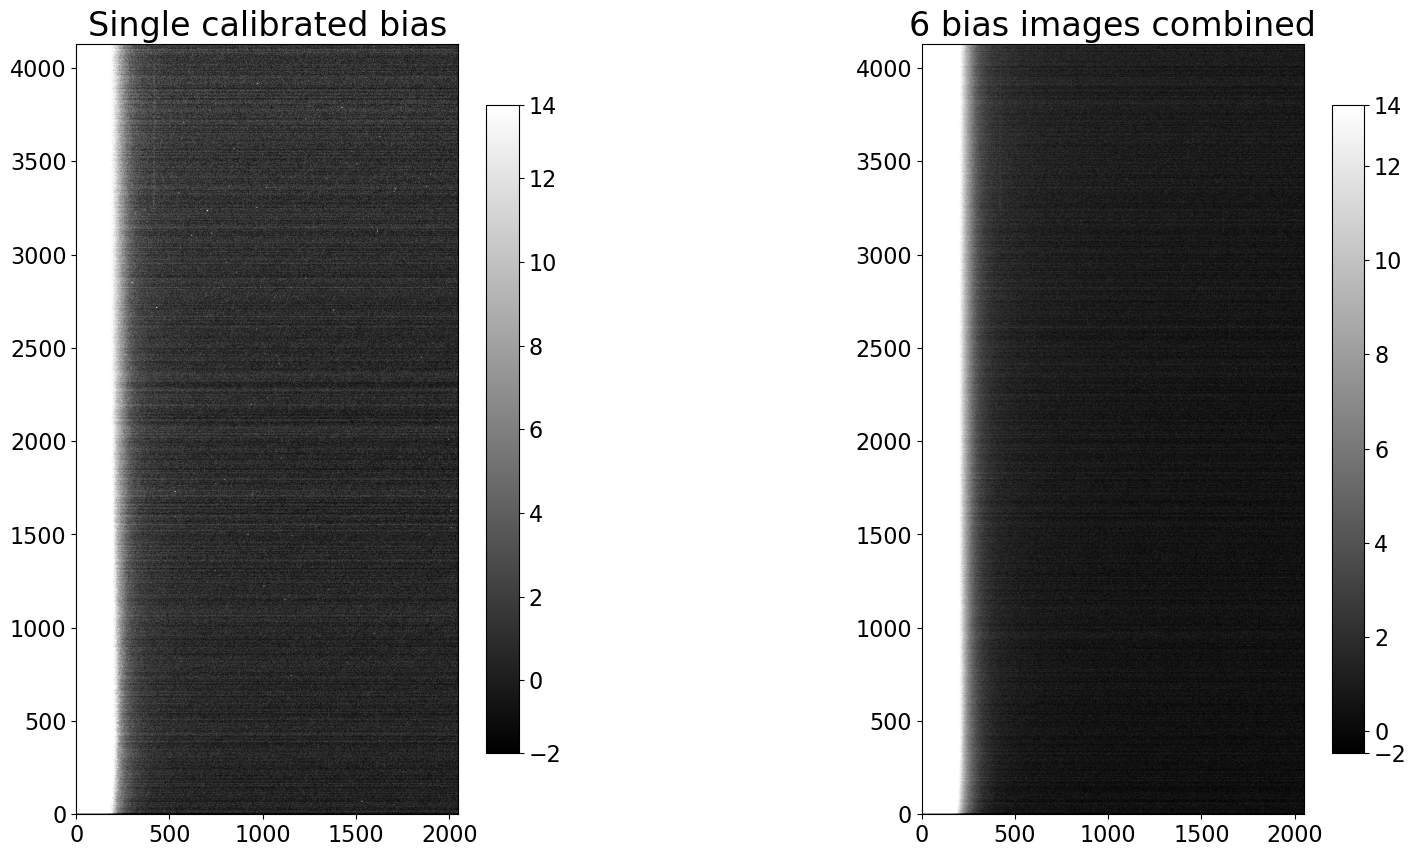

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

show_image(CCDData.read(calibrated_biases[0]).data, cmap='gray', ax=ax1, fig=fig, percl=90)
ax1.set_title('Single calibrated bias')
    # percl=90 -> ajusta o contraste; usa o percentil 90 como valor máximo para melhor visualização

show_image(combined_bias.data, cmap='gray', ax=ax2, fig=fig, percl=90)
ax2.set_title('{} bias images combined'.format(len(calibrated_biases)))
    # .format(len(calibrated_biases) -> substitui {} pelo número de imagens combinadas
    # len(calibrated_biases) -> retorna quantos arquivos estão na lista (no exemplo, 6)

# Example 2: Thermo-electrically cooled camera

The process for combining the images is exactly the same as in example 1. The only difference <u>is the directory</u> that contains the calibrated bias frames.

calibrated_path = Path('example2-reduced')
reduced_images = ccdp.ImageFileCollection(calibrated_path)

The code below:

- selects the calibrated bias images,

- combines them using the <span style="color: #d62495">combine</span> function,

- adds the keyword <span style="color: #d62495">COMBINED</span> to the header so that later calibration steps can easily identify which bias to use, and

- writes the file.

In [9]:
calibrated_biases = reduced_images.files_filtered(imagetyp='bias', include_path=True)

combined_bias = ccdp.combine(calibrated_biases,
                            method='average',
                            sigma_clip=True, sigma_clip_low_thresh=5, sigma_clip_high_thresh=5,
                            sigma_clip_func = np.ma.median, sigma_clip_dev_func=mad_std,
                            mem_limit=350e6)
combined_bias.meta['combined']=True
combined_bias.write(calibrated_path / 'combined_bias.fit')

INFO:astropy:splitting each image into 22 chunks to limit memory usage to 350000000.0 bytes.


INFO: splitting each image into 22 chunks to limit memory usage to 350000000.0 bytes. [ccdproc.combiner]


## Result for Example 2

The difference between a single calibrated bias image and the combined bias image is <u>much clearer in this case.</u>

Text(0.5, 1.0, '10 bias image combined')

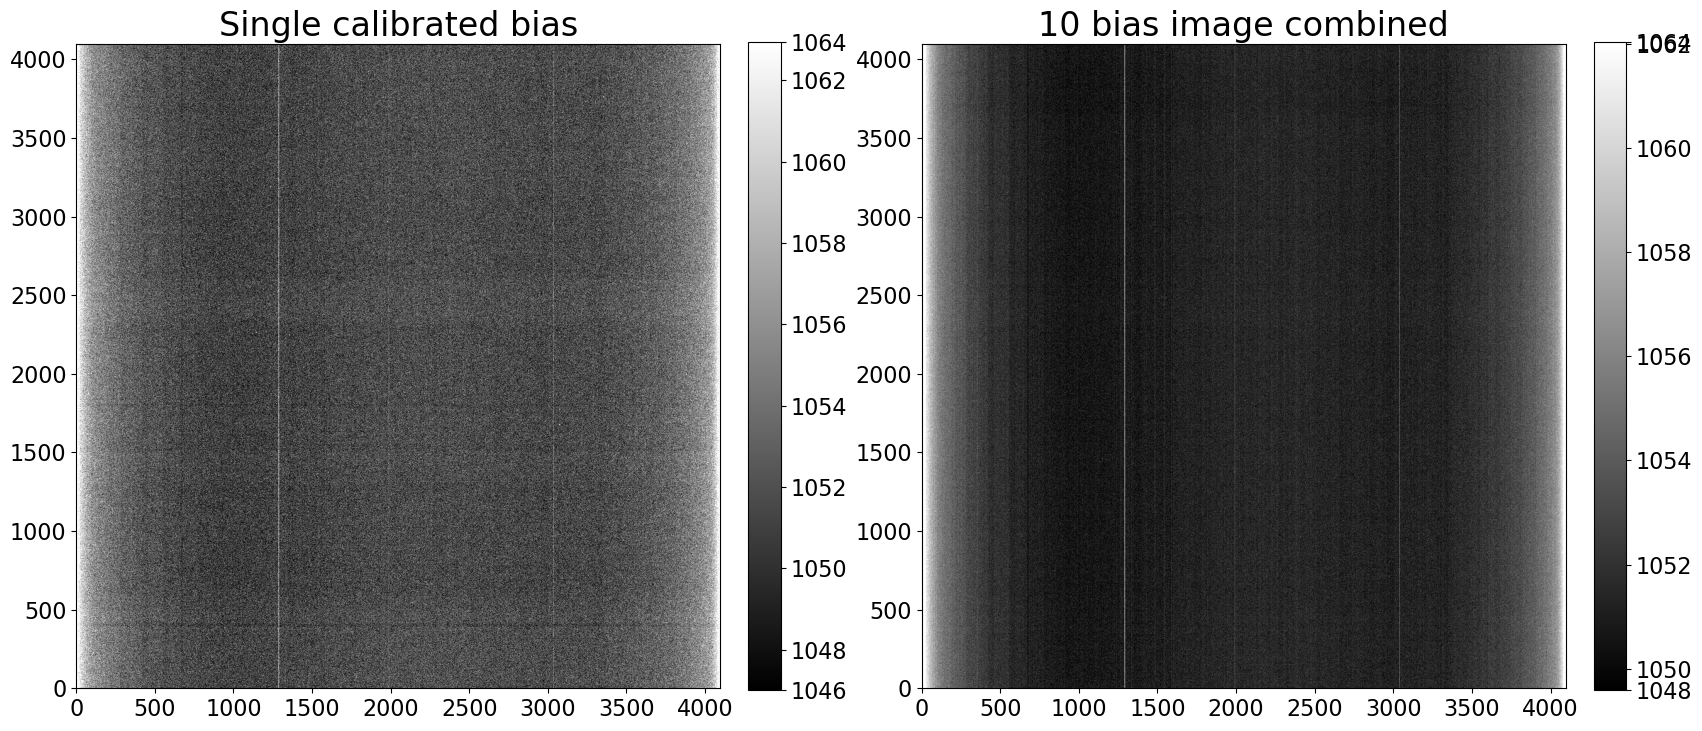

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

show_image(CCDData.read(calibrated_biases[0]).data, cmap='gray', ax=ax1, fig=fig)
ax1.set_title('Single calibrated bias')

show_image(combined_bias.data, cmap='gray', ax=ax2, fig=fig)
ax2.set_title('{} bias image combined'.format(len(calibrated_biases)))

<h1 style="text-align: left; font-family: 'menlo'; color: #FA9500; font-size:40px;">
  <span style="background-color: #FFF243; padding: 5px 10px; border-radius: 5px; display: inline-block;">
         Links
  </span>
</h1>

https://github.com/sh4rkNy/astropy-coisas/tree/main<br>https://github.com/astropy/ccd-reduction-and-photometry-guide<br>https://www.astropy.org/ccd-reduction-and-photometry-guide/v/dev/notebooks/02-04-Combine-bias-images-to-make-master.html